# Toy Conditional Trajectory DDPM

This notebook is the first end-to-end experiment for the SICNav-Diffusion reproduction. It stays entirely in the synthetic, open-loop forecasting setting.

We will:

1. Inspect cached synthetic left/straight/right trajectories.
2. Overfit a tiny dataset to test the implementation.
3. Train a conditional DDPM on the normal synthetic split.
4. Run the full reverse diffusion chain to sample multiple futures for one past.
5. Optionally compare against a deterministic MSE baseline.

This is not yet ETH/UCY evaluation or CrowdSim navigation.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

repo_root = Path.cwd()
if not (repo_root / 'toy_diffusion').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from toy_diffusion.data import TrajectoryDataset
from toy_diffusion.diffusion import denoise, noise
from toy_diffusion.models import Denoiser

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type != 'mps':
    print('MPS is unavailable, so this notebook will run on CPU.')

Using device: mps


In [2]:
SEED = 32
OBS_LEN = 50
PRED_LEN = 10
BATCH_SIZE = 128
NUM_WORKERS = 0  # Keep this at zero until the pipeline is fully debugged.

def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(SEED)

def make_loader(dataset, batch_size, shuffle):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == 'cuda',
    )

def flatten_batch(past, future):
    return past.flatten(start_dim=1).to(device), future.flatten(start_dim=1).to(device)

## 1. Inspect the synthetic data

The cached data stores one latent mode per trajectory: `-1` for right, `0` for straight, and `+1` for left. The Dataset returns positions in a local frame, so every observed past ends at `(0, 0)`.

In [3]:
train_dataset = TrajectoryDataset('train', seed=SEED)
val_dataset = TrajectoryDataset('val', seed=SEED)
print(f'Train examples: {len(train_dataset):,}')
print(f'Validation examples: {len(val_dataset):,}')
print(f'Past/future shape: {train_dataset[0][0].shape} / {train_dataset[0][1].shape}')
print('Modes:', {int(mode): int((train_dataset.modes == mode).sum()) for mode in [-1, 0, 1]})

Train examples: 10,000
Validation examples: 2,000
Past/future shape: torch.Size([50, 2]) / torch.Size([10, 2])
Modes: {-1: 3301, 0: 3347, 1: 3352}


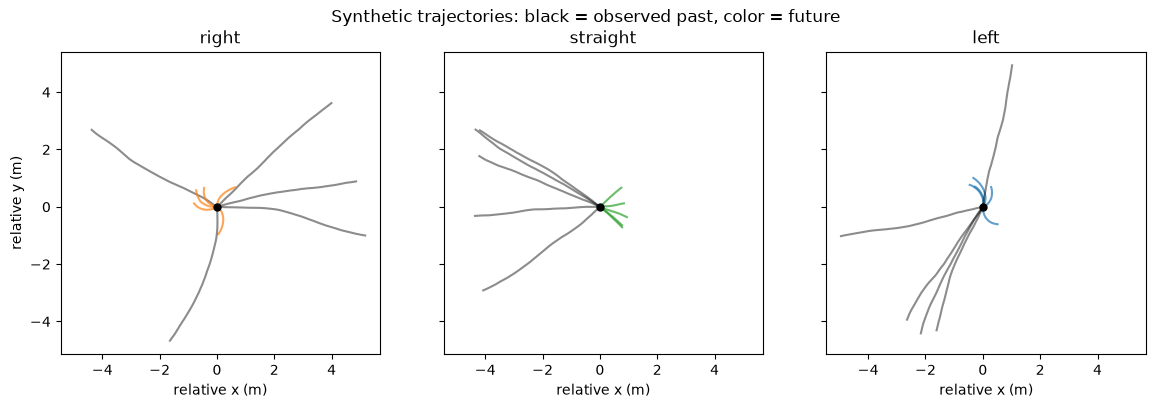

In [4]:
mode_names = {-1: 'right', 0: 'straight', 1: 'left'}
mode_colors = {-1: 'tab:orange', 0: 'tab:green', 1: 'tab:blue'}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for axis, mode in zip(axes, [-1, 0, 1]):
    indices = torch.where(train_dataset.modes == mode)[0][:5]
    for index in indices.tolist():
        past, future = train_dataset[index]
        axis.plot(past[:, 0], past[:, 1], color='black', alpha=0.45)
        axis.plot(future[:, 0], future[:, 1], color=mode_colors[mode], alpha=0.7)
    axis.scatter(0, 0, color='black', s=25, zorder=3)
    axis.set_title(mode_names[mode])
    axis.set_aspect('equal')
    axis.set_xlabel('relative x (m)')
axes[0].set_ylabel('relative y (m)')
fig.suptitle('Synthetic trajectories: black = observed past, color = future')
plt.show()

## 2. Training and validation helpers

The DDPM objective is epsilon MSE. The extra ADE/FDE diagnostic reconstructs `x_0_hat` directly from a known corrupted held-out future; it is not full generative sampling.

In [5]:
def reconstruction_metrics(future_flat, x_t, epsilon_pred, alpha_bars, timesteps):
    alpha_bar_t = alpha_bars[timesteps].unsqueeze(-1)
    future_estimate = (
        x_t - torch.sqrt(1 - alpha_bar_t) * epsilon_pred
    ) / torch.sqrt(alpha_bar_t)
    true_points = future_flat.view(-1, PRED_LEN, 2)
    estimated_points = future_estimate.view(-1, PRED_LEN, 2)
    point_errors = torch.linalg.vector_norm(estimated_points - true_points, dim=-1)
    return point_errors.mean().item(), point_errors[:, -1].mean().item()

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    loss_sum = ade_sum = fde_sum = 0.0
    batch_count = 0

    for past, future in loader:
        past_flat, future_flat = flatten_batch(past, future)
        timesteps = torch.randint(
            0, model.num_diffusion_steps, (past_flat.shape[0],), device=device
        )
        epsilon = torch.randn_like(future_flat)
        x_t = noise(timesteps, model.alpha_bars, future_flat, epsilon)

        if training:
            optimizer.zero_grad()
            epsilon_pred = model(x_t, past_flat, timesteps)
            loss = torch.nn.functional.mse_loss(epsilon_pred, epsilon)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                epsilon_pred = model(x_t, past_flat, timesteps)
                loss = torch.nn.functional.mse_loss(epsilon_pred, epsilon)

        ade, fde = reconstruction_metrics(
            future_flat, x_t, epsilon_pred, model.alpha_bars, timesteps
        )
        loss_sum += loss.item()
        ade_sum += ade
        fde_sum += fde
        batch_count += 1

    return {
        'epsilon_mse': loss_sum / batch_count,
        'denoising_ade': ade_sum / batch_count,
        'denoising_fde': fde_sum / batch_count,
    }

def fit_ddpm(model, train_loader, val_loader, epochs, learning_rate=1e-3):
    optimizer = Adam(model.parameters(), lr=learning_rate)
    history = {'train_mse': [], 'val_mse': [], 'val_ade': [], 'val_fde': []}
    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer)
        val_metrics = run_epoch(model, val_loader)
        history['train_mse'].append(train_metrics['epsilon_mse'])
        history['val_mse'].append(val_metrics['epsilon_mse'])
        history['val_ade'].append(val_metrics['denoising_ade'])
        history['val_fde'].append(val_metrics['denoising_fde'])
        print(
            f"epoch {epoch:03d} | train MSE {train_metrics['epsilon_mse']:.4f} | "
            f"val MSE {val_metrics['epsilon_mse']:.4f} | "
            f"val ADE {val_metrics['denoising_ade']:.4f} | "
            f"val FDE {val_metrics['denoising_fde']:.4f}"
        )
    return history

## 3. Tiny overfit test

Before training normally, make the model memorize a tiny fixed set. The metric values should fall substantially. If they do not, debug this stage before spending time on a full run.

In [6]:
RUN_OVERFIT_TEST = True
OVERFIT_SIZE = 64
OVERFIT_EPOCHS = 100

if RUN_OVERFIT_TEST:
    overfit_dataset = TrajectoryDataset(
        'train', seed=SEED + 1, train_size=OVERFIT_SIZE, val_size=OVERFIT_SIZE
    )
    overfit_loader = make_loader(overfit_dataset, OVERFIT_SIZE, shuffle=True)
    overfit_model = Denoiser().to(device)
    overfit_history = fit_ddpm(
        overfit_model, overfit_loader, overfit_loader, OVERFIT_EPOCHS
    )

epoch 001 | train MSE 1.0116 | val MSE 0.9572 | val ADE 0.7078 | val FDE 0.7178
epoch 002 | train MSE 1.0027 | val MSE 0.9483 | val ADE 0.6108 | val FDE 0.5644
epoch 003 | train MSE 0.8840 | val MSE 1.0101 | val ADE 0.7477 | val FDE 0.7798
epoch 004 | train MSE 1.0126 | val MSE 0.9814 | val ADE 0.7799 | val FDE 0.8818
epoch 005 | train MSE 0.9747 | val MSE 0.9697 | val ADE 0.8358 | val FDE 0.8403
epoch 006 | train MSE 0.9748 | val MSE 0.9660 | val ADE 0.7409 | val FDE 0.7621
epoch 007 | train MSE 1.0352 | val MSE 1.0382 | val ADE 0.7585 | val FDE 0.6344
epoch 008 | train MSE 0.9217 | val MSE 0.9756 | val ADE 0.7241 | val FDE 0.7638
epoch 009 | train MSE 0.9408 | val MSE 0.9421 | val ADE 0.7863 | val FDE 0.7807
epoch 010 | train MSE 0.9406 | val MSE 0.9577 | val ADE 0.7490 | val FDE 0.7584
epoch 011 | train MSE 0.9417 | val MSE 0.9893 | val ADE 0.7584 | val FDE 0.7498
epoch 012 | train MSE 1.0003 | val MSE 0.9957 | val ADE 0.7971 | val FDE 0.7192
epoch 013 | train MSE 0.9397 | val MSE 0

## 4. Normal training run

Set `RUN_FULL_TRAINING` to `True` after the data plots and tiny overfit test look healthy. The checkpoint is saved under `toy_diffusion/outputs/`, which is ignored by git.

In [15]:
RUN_FULL_TRAINING = True
FULL_EPOCHS = 500

if RUN_FULL_TRAINING:
    set_seed(SEED)
    train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(val_dataset, BATCH_SIZE, shuffle=False)
    model = Denoiser().to(device)
    history = fit_ddpm(model, train_loader, val_loader, FULL_EPOCHS)

    outputs_dir = repo_root / 'toy_diffusion' / 'outputs'
    outputs_dir.mkdir(exist_ok=True)
    checkpoint_path = outputs_dir / f'toy_ddpm_seed{SEED}.pt'
    torch.save({'model_state_dict': model.state_dict(), 'history': history}, checkpoint_path)
    print(f'Saved checkpoint to {checkpoint_path}')

epoch 001 | train MSE 0.7956 | val MSE 0.5543 | val ADE 0.4704 | val FDE 0.4999
epoch 002 | train MSE 0.3958 | val MSE 0.2948 | val ADE 0.2904 | val FDE 0.4087
epoch 003 | train MSE 0.2675 | val MSE 0.2550 | val ADE 0.2473 | val FDE 0.3505
epoch 004 | train MSE 0.2392 | val MSE 0.2248 | val ADE 0.2415 | val FDE 0.3726
epoch 005 | train MSE 0.2254 | val MSE 0.2242 | val ADE 0.2343 | val FDE 0.3674
epoch 006 | train MSE 0.2144 | val MSE 0.2098 | val ADE 0.2297 | val FDE 0.3629
epoch 007 | train MSE 0.2042 | val MSE 0.1942 | val ADE 0.2228 | val FDE 0.3567
epoch 008 | train MSE 0.1923 | val MSE 0.1798 | val ADE 0.2149 | val FDE 0.3475
epoch 009 | train MSE 0.1801 | val MSE 0.1822 | val ADE 0.2051 | val FDE 0.3238
epoch 010 | train MSE 0.1745 | val MSE 0.1763 | val ADE 0.2032 | val FDE 0.3309
epoch 011 | train MSE 0.1666 | val MSE 0.1705 | val ADE 0.2014 | val FDE 0.3388
epoch 012 | train MSE 0.1624 | val MSE 0.1535 | val ADE 0.2022 | val FDE 0.3209
epoch 013 | train MSE 0.1591 | val MSE 0

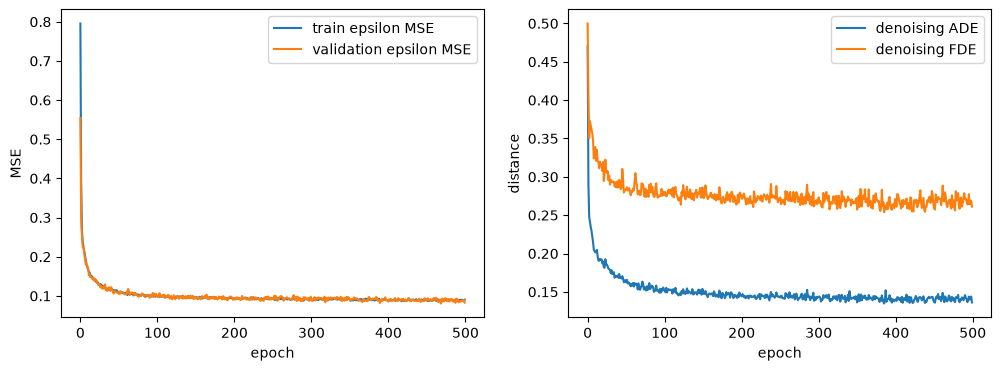

In [16]:
if RUN_FULL_TRAINING:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_mse'], label='train epsilon MSE')
    axes[0].plot(history['val_mse'], label='validation epsilon MSE')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    axes[1].plot(history['val_ade'], label='denoising ADE')
    axes[1].plot(history['val_fde'], label='denoising FDE')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('distance')
    axes[1].legend()
    plt.show()

## 5. Full reverse diffusion sampling

Unlike direct `x_0` reconstruction, this starts from pure Gaussian noise and runs every reverse diffusion step. Repeating the same past context `K` times lets us draw `K` plausible futures for it.

In [17]:
@torch.no_grad()
def sample_futures(model, past, num_samples=30):
    model.eval()
    past_flat = past.flatten().unsqueeze(0).repeat(num_samples, 1).to(device)
    x_t = torch.randn(num_samples, PRED_LEN * 2, device=device)

    for timestep in reversed(range(model.num_diffusion_steps)):
        timesteps = torch.full(
            (num_samples,), timestep, device=device, dtype=torch.long
        )
        epsilon_pred = model(x_t, past_flat, timesteps)
        x_t = denoise(timestep, model.betas, model.alpha_bars, x_t, epsilon_pred)

    return x_t.view(num_samples, PRED_LEN, 2).cpu()

def plot_samples(past, future, samples, title):
    fig, axis = plt.subplots(figsize=(6, 6))
    for sample in samples:
        axis.plot(sample[:, 0], sample[:, 1], color='tab:blue', alpha=0.22)
    axis.plot(past[:, 0], past[:, 1], color='black', linewidth=2, label='observed past')
    axis.plot(future[:, 0], future[:, 1], color='tab:green', linewidth=2, label='held-out future')
    axis.scatter(0, 0, color='black', s=35, zorder=3)
    axis.set_aspect('equal')
    axis.set_xlabel('relative x (m)')
    axis.set_ylabel('relative y (m)')
    axis.set_title(title)
    axis.legend()
    plt.show()

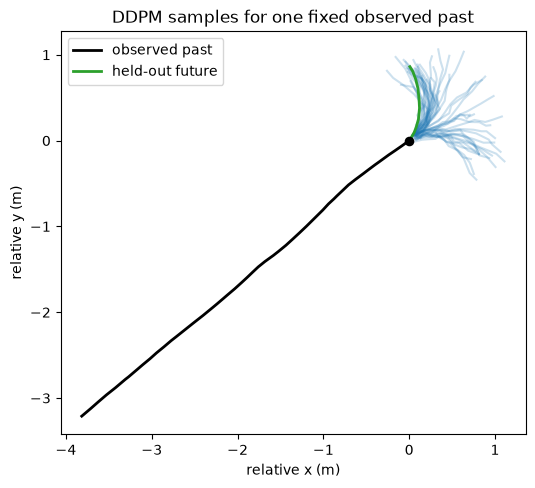

In [18]:
# Run this after full training, or load a saved checkpoint into `model`.
if RUN_FULL_TRAINING:
    sample_index = int(torch.where(val_dataset.modes == 1)[0][0])
    past, future = val_dataset[sample_index]
    sampled_futures = sample_futures(model, past, num_samples=50)
    plot_samples(past, future, sampled_futures, 'DDPM samples for one fixed observed past')

## 6. Optional deterministic baseline

This baseline produces exactly one future from each past and is trained with coordinate MSE. On truly ambiguous contexts, it should tend toward an average route. It is included here for visual contrast, not because it is expected to beat diffusion at multimodal sampling.

baseline epoch 001 | MSE 0.0628
baseline epoch 002 | MSE 0.0558
baseline epoch 003 | MSE 0.0558
baseline epoch 004 | MSE 0.0557
baseline epoch 005 | MSE 0.0554
baseline epoch 006 | MSE 0.0554
baseline epoch 007 | MSE 0.0555
baseline epoch 008 | MSE 0.0554
baseline epoch 009 | MSE 0.0549
baseline epoch 010 | MSE 0.0552
baseline epoch 011 | MSE 0.0548
baseline epoch 012 | MSE 0.0549
baseline epoch 013 | MSE 0.0551
baseline epoch 014 | MSE 0.0548
baseline epoch 015 | MSE 0.0550
baseline epoch 016 | MSE 0.0548
baseline epoch 017 | MSE 0.0547
baseline epoch 018 | MSE 0.0549
baseline epoch 019 | MSE 0.0548
baseline epoch 020 | MSE 0.0546
baseline epoch 021 | MSE 0.0548
baseline epoch 022 | MSE 0.0547
baseline epoch 023 | MSE 0.0547
baseline epoch 024 | MSE 0.0544
baseline epoch 025 | MSE 0.0546
baseline epoch 026 | MSE 0.0542
baseline epoch 027 | MSE 0.0542
baseline epoch 028 | MSE 0.0543
baseline epoch 029 | MSE 0.0544
baseline epoch 030 | MSE 0.0545
baseline epoch 031 | MSE 0.0544
baseline

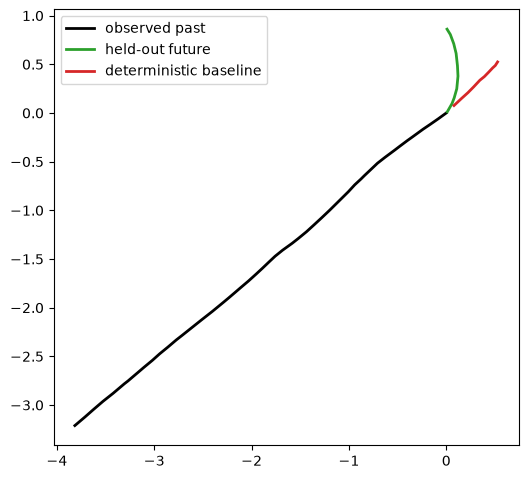

In [20]:
class DeterministicBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(OBS_LEN * 2, 200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, PRED_LEN * 2),
        )

    def forward(self, past):
        return self.network(past)

def train_baseline(model, train_loader, epochs=50, learning_rate=1e-3):
    optimizer = Adam(model.parameters(), lr=learning_rate)
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for past, future in train_loader:
            past_flat, future_flat = flatten_batch(past, future)
            optimizer.zero_grad()
            loss = torch.nn.functional.mse_loss(model(past_flat), future_flat)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        print(f'baseline epoch {epoch:03d} | MSE {loss_sum / len(train_loader):.4f}')
    return model

RUN_BASELINE = True
if RUN_BASELINE:
    baseline_train_loader = make_loader(train_dataset, BATCH_SIZE, shuffle=True)
    baseline = DeterministicBaseline().to(device)
    baseline = train_baseline(baseline, baseline_train_loader)
    sample_index = int(torch.where(val_dataset.modes == 1)[0][0])
    past, future = val_dataset[sample_index]
    with torch.no_grad():
        baseline_future = baseline(past.flatten().unsqueeze(0).to(device)).view(PRED_LEN, 2).cpu()
    plt.figure(figsize=(6, 6))
    plt.plot(past[:, 0], past[:, 1], color='black', linewidth=2, label='observed past')
    plt.plot(future[:, 0], future[:, 1], color='tab:green', linewidth=2, label='held-out future')
    plt.plot(baseline_future[:, 0], baseline_future[:, 1], color='tab:red', linewidth=2, label='deterministic baseline')
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.show()

## What success looks like

- Dataset plots show smooth relative left, straight, and right futures.
- The tiny overfit run drives epsilon MSE and reconstruction ADE/FDE down.
- Normal-training validation metrics improve without a large train/validation gap.
- Reverse samples are smooth trajectories rather than a random point cloud.
- For one fixed past, many DDPM samples begin to cover multiple plausible branches.

After that, the next milestone is the same open-loop workflow on ETH/UCY, before any CrowdSim or robot-planning integration.